In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Load clean combined dataset
df = pd.read_csv(r"C:\ShieldNet-AI\data\cic_aligned_training.csv")

df.shape


(2313810, 7)

In [4]:
# Define features and target
# Feature columns
X = df.drop(columns=['Label'])

# Target column
y = df['Label']


In [5]:
# Convert labels to numeric
y = y.map({
    'Benign': 0,
    'Attack': 1
})
y.value_counts()



Label
0.0    1977318
Name: count, dtype: int64

In [6]:
# Handle infinite & missing values
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.dropna(inplace=True)

# Align y with cleaned X
y = y.loc[X.index]



In [7]:
print(y.isna().sum())

336492


In [8]:
print(y.unique())

[ 0. nan]


In [9]:
import pandas as pd

print(df[df['Label'].isna()])

df = df.dropna(subset=['Label'])

Empty DataFrame
Columns: [Flow Duration, Total Fwd Packets, Total Bwd Packets, Total Length Fwd, Fwd Packet Max, Idle Mean, Label]
Index: []


In [10]:
df = df.dropna(subset=['Label'])

X = df.drop('Label', axis=1)
y = df['Label']

In [11]:
# Train–Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (1851048, 6)
Test shape: (462762, 6)


In [12]:
print("Train label distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True))


Train label distribution:
Label
Benign                        0.854572
DoS Hulk                      0.074702
DDoS                          0.055326
DoS GoldenEye                 0.004446
FTP-Patator                   0.002563
DoS slowloris                 0.002327
DoS Slowhttptest              0.002259
SSH-Patator                   0.001391
PortScan                      0.000845
Web Attack � Brute Force      0.000635
Bot                           0.000621
Web Attack � XSS              0.000282
Infiltration                  0.000016
Web Attack � Sql Injection    0.000009
Heartbleed                    0.000005
Name: proportion, dtype: float64

Test label distribution:
Label
Benign                        0.854573
DoS Hulk                      0.074701
DDoS                          0.055326
DoS GoldenEye                 0.004445
FTP-Patator                   0.002563
DoS slowloris                 0.002327
DoS Slowhttptest              0.002260
SSH-Patator                   0.001392
PortSc

In [13]:
# Feature Scaling Cell

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data (important to avoid data leakage)
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to test data
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)


Scaled train shape: (1851048, 6)
Scaled test shape: (462762, 6)


C:\Users\KUSHAL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression - Classification Report
              precision    recall  f1-score   support

           0       0.92      0.96      0.94    395464
           1       0.67      0.52      0.58     67298

    accuracy                           0.89    462762
   macro avg       0.80      0.74      0.76    462762
weighted avg       0.88      0.89      0.89    462762



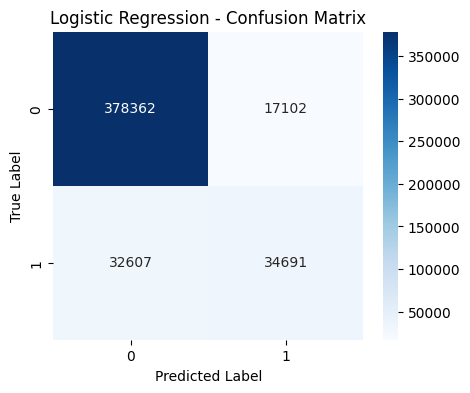

In [16]:
# LOGISTIC REGRESSION 

# Import model + metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train Logistic Regression
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1
)

log_reg.fit(X_train_scaled, y_train)

# Prediction
y_pred_lr = log_reg.predict(X_test_scaled)


# Evaluate the model
print("Logistic Regression - Classification Report")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


Random Forest - Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    395464
           1       0.98      0.98      0.98     67298

    accuracy                           0.99    462762
   macro avg       0.99      0.99      0.99    462762
weighted avg       0.99      0.99      0.99    462762



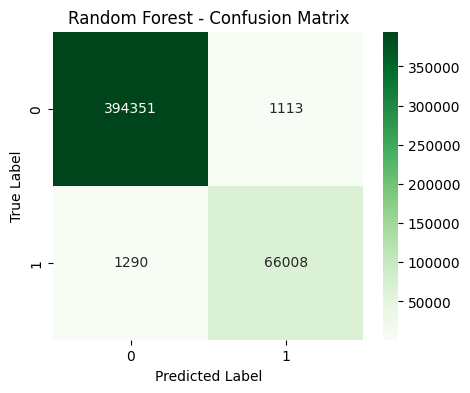

In [26]:
#RANDOM FOREST 

# Initialize Random Forest model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=100,        # number of trees
    max_depth=None,          # let trees grow fully
    class_weight='balanced', # handle class imbalance
    random_state=42,
    n_jobs=-1                # use all CPU cores
)

# Train the model (UNSCALED data)
rf.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf.predict(X_test)

# Evaluate Random Forest
print("Random Forest - Classification Report")
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


SVM training subset shape: (100000, 6)
SVM training label distribution:
Label
0    85457
1    14543
Name: count, dtype: int64

Training SVM model...
SVM training completed.

SVM - Classification Report
              precision    recall  f1-score   support

           0       0.92      0.96      0.94    395464
           1       0.68      0.50      0.57     67298

    accuracy                           0.89    462762
   macro avg       0.80      0.73      0.76    462762
weighted avg       0.88      0.89      0.89    462762



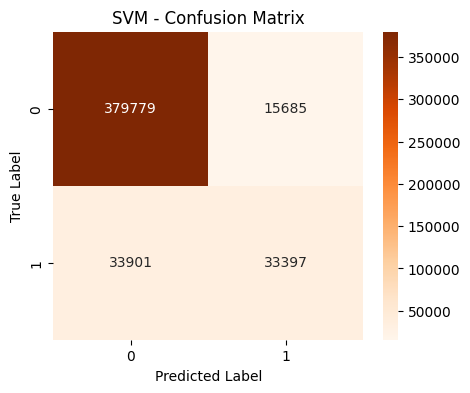

In [20]:
# =========================
# SUPPORT VECTOR MACHINE (SVM)


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

# Create a stratified subset for SVM training

sss = StratifiedShuffleSplit(
    n_splits=1,
    train_size=100000,
    random_state=42
)

for train_idx, _ in sss.split(X_train_scaled, y_train):
    X_train_svm = X_train_scaled[train_idx]
    y_train_svm = y_train.iloc[train_idx]

print("SVM training subset shape:", X_train_svm.shape)
print("SVM training label distribution:")
print(y_train_svm.value_counts())


# Initialize SVM model

svm_model = SVC(
    kernel='linear',
    class_weight='balanced',
    random_state=42
)


# Train SVM model

print("\nTraining SVM model...")
svm_model.fit(X_train_svm, y_train_svm)
print("SVM training completed.")


# Predict on FULL test set

y_pred_svm = svm_model.predict(X_test_scaled)


# Evaluation

print("\nSVM - Classification Report")
print(classification_report(y_test, y_pred_svm))


# Confusion Matrix Visualization

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:
# DEEP LEARNING 
# Prepare DL data
# We’ll train DL on 100,000 samples (balanced + safe).

from sklearn.model_selection import StratifiedShuffleSplit

# Create a stratified subset for Deep Learning
sss_dl = StratifiedShuffleSplit(
    n_splits=1,
    train_size=100000,
    random_state=42
)

for train_idx, _ in sss_dl.split(X_train_scaled, y_train):
    X_train_dl = X_train_scaled[train_idx]
    y_train_dl = y_train.iloc[train_idx]

print("DL training data shape:", X_train_dl.shape)
print("DL label distribution:")
print(y_train_dl.value_counts()) 


DL training data shape: (100000, 6)
DL label distribution:
Label
0    85457
1    14543
Name: count, dtype: int64


In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


DL training shape: (100000, 6)
DL label distribution:
Label
0    85457
1    14543
Name: count, dtype: int64


C:\Users\KUSHAL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,561 (10.00 KB)

 Trainable params: 2,561 (10.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8741 - loss: 0.4563 - val_accuracy: 0.9052 - val_loss: 0.2867
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9030 - loss: 0.2993 - val_accuracy: 0.9054 - val_loss: 0.2804
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9036 - loss: 0.2921 - val_accuracy: 0.9058 - val_loss: 0.2758
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9055 - loss: 0.2852 - val_accuracy: 0.9074 - val_loss: 0.2708
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9066 - loss: 0.2794 - val_accuracy: 0.9125 - val_loss: 0.2658
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9093 - loss: 0.2741 - val_accuracy: 0.9144 - val_loss: 0.2613
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9107 - loss: 0.2688 - val_accuracy: 0.9141 - val_loss: 0.2570
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9113 - loss: 0.2642 - val_accuracy: 0.9146 - val_loss:

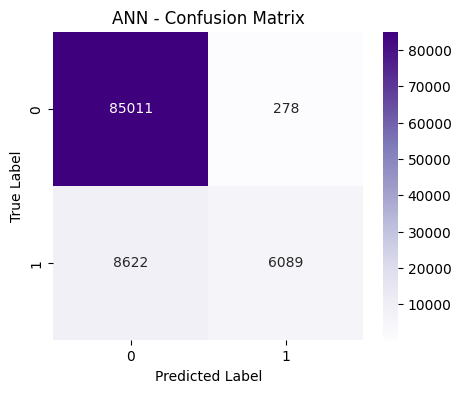

In [9]:
# =========================================
# ANN (Artificial Neural Network) - SINGLE CELL
# =========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------------------
# STEP 1: Create a stratified subset for DL
# -----------------------------------------
# We DO NOT train DL on full data (too slow)
# 100k samples is more than enough and acceptable

sss_dl = StratifiedShuffleSplit(
    n_splits=1,
    train_size=100000,
    random_state=42
)

for train_idx, _ in sss_dl.split(X_train_scaled, y_train):
    X_train_dl = X_train_scaled[train_idx]
    y_train_dl = y_train.iloc[train_idx]

print("DL training shape:", X_train_dl.shape)
print("DL label distribution:")
print(y_train_dl.value_counts())

# -----------------------------------------
# STEP 2: Build ANN model
# -----------------------------------------

ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_dl.shape[1],)),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    Dropout(0.3),
    
    Dense(1, activation='sigmoid')  # Binary classification
])

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

# -----------------------------------------
# STEP 3: Train ANN (optimized for speed)
# -----------------------------------------

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = ann_model.fit(
    X_train_dl,
    y_train_dl,
    epochs=10,          # keep small
    batch_size=1024,    # faster on CPU
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# -----------------------------------------
# STEP 4: Evaluate ANN (subset of test for speed)
# -----------------------------------------

X_test_dl = X_test_scaled[:100000]
y_test_dl = y_test.iloc[:100000]

y_pred_prob = ann_model.predict(X_test_dl)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("\nANN - Classification Report")
print(classification_report(y_test_dl, y_pred))

# -----------------------------------------
# STEP 5: Confusion Matrix
# -----------------------------------------

cm = confusion_matrix(y_test_dl, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("ANN - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


DNN training shape: (100000, 6)
DNN label distribution:
Label
0    85457
1    14543
Name: count, dtype: int64


C:\Users\KUSHAL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,265 (44.00 KB)

 Trainable params: 11,265 (44.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8869 - loss: 0.3758 - val_accuracy: 0.9041 - val_loss: 0.2829
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9039 - loss: 0.2917 - val_accuracy: 0.9079 - val_loss: 0.2736
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9058 - loss: 0.2801 - val_accuracy: 0.9121 - val_loss: 0.2617
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9102 - loss: 0.2664 - val_accuracy: 0.9162 - val_loss: 0.2496
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9136 - loss: 0.2565 - val_accuracy: 0.9172 - val_loss: 0.2408
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9152 - loss: 0.2457 - val_accuracy: 0.9200 - val_loss: 0.2318
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9164 - loss: 0.2367 - val_accuracy: 0.9208 - val_loss: 0.2228
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9167 - loss: 0.2288 - val_accuracy: 0.9201 - val_loss:

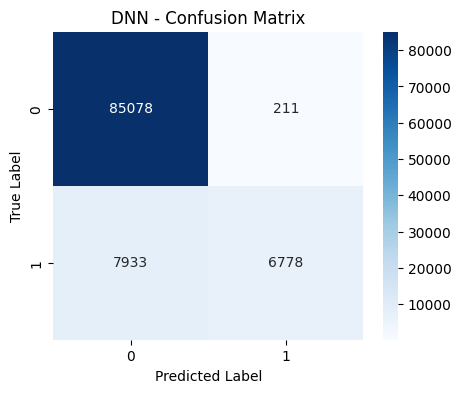

In [10]:
# =========================================
# DNN (Deep Neural Network)
# =========================================
# Differences from ANN:
# - More hidden layers (deeper network)
# - Better feature representation
# - Still suitable for tabular data
# =========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------------------
# STEP 1: Create a stratified DL subset
# -----------------------------------------
# Using 100k samples for speed and stability

sss_dl = StratifiedShuffleSplit(
    n_splits=1,
    train_size=100000,
    random_state=42
)

for train_idx, _ in sss_dl.split(X_train_scaled, y_train):
    X_train_dl = X_train_scaled[train_idx]
    y_train_dl = y_train.iloc[train_idx]

print("DNN training shape:", X_train_dl.shape)
print("DNN label distribution:")
print(y_train_dl.value_counts())

# -----------------------------------------
# STEP 2: Build DNN model (DEEPER than ANN)
# -----------------------------------------

dnn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_dl.shape[1],)),
    Dropout(0.4),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')  # Binary classification
])

dnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

dnn_model.summary()

# -----------------------------------------
# STEP 3: Train DNN (CPU-optimized)
# -----------------------------------------

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = dnn_model.fit(
    X_train_dl,
    y_train_dl,
    epochs=10,          # keep small
    batch_size=1024,    # fast on CPU
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# -----------------------------------------
# STEP 4: Evaluate DNN (test subset for speed)
# -----------------------------------------

X_test_dl = X_test_scaled[:100000]
y_test_dl = y_test.iloc[:100000]

y_pred_prob = dnn_model.predict(X_test_dl)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("\nDNN - Classification Report")
print(classification_report(y_test_dl, y_pred))

# -----------------------------------------
# STEP 5: Confusion Matrix
# -----------------------------------------

cm = confusion_matrix(y_test_dl, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("DNN - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


Autoencoder training data shape (Benign only): (50000, 6)


C:\Users\KUSHAL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,494 (5.84 KB)

 Trainable params: 1,494 (5.84 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.1957 - val_loss: 0.2624
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.7096 - val_loss: 0.0918
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.4023 - val_loss: 0.0567
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.0584 - val_loss: 0.0433
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.7855 - val_loss: 0.0352
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.4272 - val_loss: 0.0271
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.8845 - val_loss: 0.0196
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.2606 - val_loss: 0.0095
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.4636 - val_loss: 0.0041
Epoch 10/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6556 - val_loss: 0.0025
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 2s 533us/step
Reconstruction error threshold: 0.0047739458727927495

Autoencoder - Classification Report
              precision

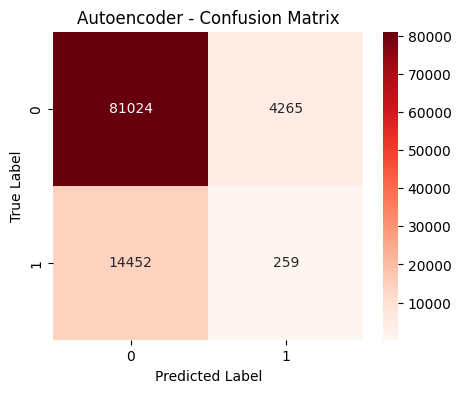

In [11]:
# =========================================
# AUTOENCODER - (ANOMALY DETECTION)
# =========================================
# Idea:
# - Train Autoencoder ONLY on benign traffic
# - It learns "normal" behavior
# - High reconstruction error => Attack
# =========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------------------
# STEP 1: Prepare BENIGN-only training data
# -----------------------------------------
# Autoencoders are trained only on normal traffic

# Select benign samples from training data
X_train_benign = X_train_scaled[y_train == 0]

# Subsample benign data for speed (50k is enough)
X_train_benign = X_train_benign[:50000]

print("Autoencoder training data shape (Benign only):", X_train_benign.shape)

# -----------------------------------------
# STEP 2: Build Autoencoder model
# -----------------------------------------

autoencoder = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_benign.shape[1],)),
    Dense(16, activation='relu'),
    Dense(32, activation='relu'),
    Dense(X_train_benign.shape[1], activation='linear')  # reconstruction
])

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

autoencoder.summary()

# -----------------------------------------
# STEP 3: Train Autoencoder
# -----------------------------------------

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

autoencoder.fit(
    X_train_benign,
    X_train_benign,
    epochs=10,
    batch_size=1024,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# -----------------------------------------
# STEP 4: Compute reconstruction error on test data
# -----------------------------------------

# Use subset of test data for speed
X_test_ae = X_test_scaled[:100000]
y_test_ae = y_test.iloc[:100000]

# Reconstruct
X_test_recon = autoencoder.predict(X_test_ae)

# Mean Squared Error per sample
reconstruction_error = np.mean(np.square(X_test_ae - X_test_recon), axis=1)

# -----------------------------------------
# STEP 5: Choose threshold
# -----------------------------------------
# Simple & standard choice: 95th percentile of benign errors

threshold = np.percentile(
    reconstruction_error[y_test_ae == 0],
    95
)

print("Reconstruction error threshold:", threshold)

# -----------------------------------------
# STEP 6: Classify samples
# -----------------------------------------
# error > threshold => Attack (1)
# else => Benign (0)

y_pred_ae = (reconstruction_error > threshold).astype(int)

# -----------------------------------------
# STEP 7: Evaluation
# -----------------------------------------

print("\nAutoencoder - Classification Report")
print(classification_report(y_test_ae, y_pred_ae))

cm = confusion_matrix(y_test_ae, y_pred_ae)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("Autoencoder - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


LSTM training shape (before reshape): (50000, 6)
LSTM label distribution:
Label
0    42729
1     7271
Name: count, dtype: int64
LSTM training shape (after reshape): (50000, 6, 1)
LSTM test shape: (50000, 6, 1)


C:\Users\KUSHAL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8735 - loss: 0.4454 - val_accuracy: 0.9063 - val_loss: 0.3325
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9058 - loss: 0.3101 - val_accuracy: 0.9027 - val_loss: 0.2969
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9060 - loss: 0.2978 - val_accuracy: 0.9042 - val_loss: 0.2961
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9058 - loss: 0.2946 - val_accuracy: 0.9024 - val_loss: 0.2923
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9056 - loss: 0.2925 - val_accuracy: 0.9030 - val_loss: 0.2914
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9057 - loss: 0.2905 - val_accuracy: 0.9030 - val_loss: 0.2905
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9059 - loss: 0.2896 - val_accuracy: 0.9028 - val_loss: 0.2877
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9060 - loss: 0.2867 - val_accuracy: 0.9028 - v

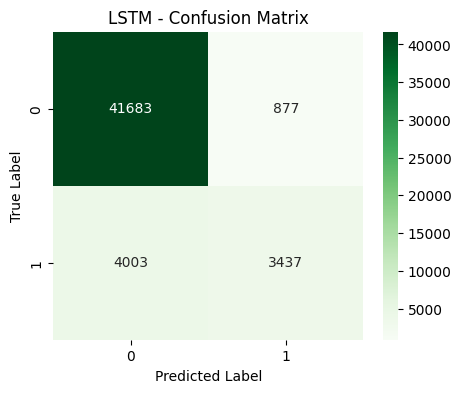

In [12]:
# =========================================
# LSTM (Long Short-Term Memory)
# =========================================
# NOTE:
# - Original data is tabular, not time-series
# - Each sample is treated as a sequence of features
# - This is a standard IDS approach for LSTM usage
# =========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------------------
# STEP 1: Create stratified DL subset
# -----------------------------------------
# Smaller subset because LSTM is heavy

sss_lstm = StratifiedShuffleSplit(
    n_splits=1,
    train_size=50000,   # smaller for LSTM
    random_state=42
)

for train_idx, _ in sss_lstm.split(X_train_scaled, y_train):
    X_train_lstm = X_train_scaled[train_idx]
    y_train_lstm = y_train.iloc[train_idx]

print("LSTM training shape (before reshape):", X_train_lstm.shape)
print("LSTM label distribution:")
print(y_train_lstm.value_counts())

# -----------------------------------------
# STEP 2: Reshape data for LSTM
# -----------------------------------------
# Shape required: (samples, timesteps, features)
# Here: timesteps = number of original features

X_train_lstm = X_train_lstm.reshape(
    X_train_lstm.shape[0],
    X_train_lstm.shape[1],
    1
)

X_test_lstm = X_test_scaled[:50000].reshape(
    50000,
    X_test_scaled.shape[1],
    1
)

y_test_lstm = y_test.iloc[:50000]

print("LSTM training shape (after reshape):", X_train_lstm.shape)
print("LSTM test shape:", X_test_lstm.shape)

# -----------------------------------------
# STEP 3: Build LSTM model
# -----------------------------------------

lstm_model = Sequential([
    LSTM(64, input_shape=(X_train_lstm.shape[1], 1), return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

# -----------------------------------------
# STEP 4: Train LSTM
# -----------------------------------------

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=10,
    batch_size=512,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# -----------------------------------------
# STEP 5: Evaluate LSTM
# -----------------------------------------

y_pred_prob = lstm_model.predict(X_test_lstm)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("\nLSTM - Classification Report")
print(classification_report(y_test_lstm, y_pred))

cm = confusion_matrix(y_test_lstm, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("LSTM - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


CNN training shape (before reshape): (100000, 6)
CNN label distribution:
Label
0    85457
1    14543
Name: count, dtype: int64
CNN training shape (after reshape): (100000, 6, 1)
CNN test shape: (100000, 6, 1)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 6, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 6, 32)          │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,849 (73.63 KB)

 Trainable params: 18,849 (73.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8808 - loss: 0.3639 - val_accuracy: 0.9038 - val_loss: 0.2831
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8996 - loss: 0.2909 - val_accuracy: 0.8970 - val_loss: 0.2741
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9007 - loss: 0.2783 - val_accuracy: 0.9003 - val_loss: 0.2602
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9047 - loss: 0.2674 - val_accuracy: 0.9132 - val_loss: 0.2479
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9091 - loss: 0.2578 - val_accuracy: 0.9143 - val_loss: 0.2366
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9128 - loss: 0.2495 - val_accuracy: 0.9166 - val_loss: 0.2311
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9145 - loss: 0.2440 - val_accuracy: 0.9215 - val_loss: 0.2259
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9157 - loss: 0.2397 - val_accuracy: 0.9215 - val_loss

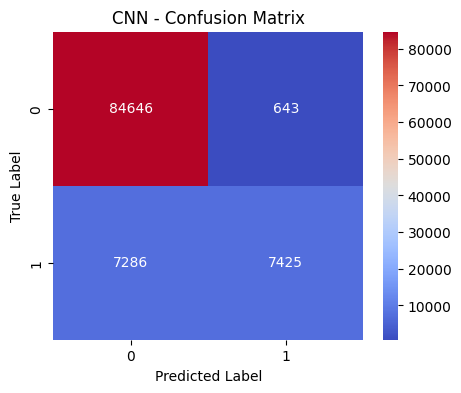

In [14]:
# =========================================
# 1D CNN (Convolutional Neural Network) 
# =========================================
# WHY CNN:
# - Learns local feature patterns
# - Works very well for IDS tabular data
# - Faster and more stable than LSTM on CPU
# =========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------------------
# STEP 1: Stratified subset
# -----------------------------------------

sss_cnn = StratifiedShuffleSplit(
    n_splits=1,
    train_size=100000,
    random_state=42
)

for train_idx, _ in sss_cnn.split(X_train_scaled, y_train):
    X_train_cnn = X_train_scaled[train_idx]
    y_train_cnn = y_train.iloc[train_idx]

print("CNN training shape (before reshape):", X_train_cnn.shape)
print("CNN label distribution:")
print(y_train_cnn.value_counts())

# -----------------------------------------
# STEP 2: Reshape for CNN
# -----------------------------------------

X_train_cnn = X_train_cnn.reshape(
    X_train_cnn.shape[0],
    X_train_cnn.shape[1],
    1
)

X_test_cnn = X_test_scaled[:100000].reshape(
    100000,
    X_test_scaled.shape[1],
    1
)

y_test_cnn = y_test.iloc[:100000]

print("CNN training shape (after reshape):", X_train_cnn.shape)
print("CNN test shape:", X_test_cnn.shape)

# -----------------------------------------
# STEP 3: Build CORRECT CNN model
# -----------------------------------------

cnn_model = Sequential([
    Input(shape=(X_train_cnn.shape[1], 1)),

    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    Dropout(0.3),

    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    Dropout(0.3),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

# -----------------------------------------
# STEP 4: Train CNN
# -----------------------------------------

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

cnn_model.fit(
    X_train_cnn,
    y_train_cnn,
    epochs=10,
    batch_size=1024,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# -----------------------------------------
# STEP 5: Evaluate CNN
# -----------------------------------------

y_pred_prob = cnn_model.predict(X_test_cnn)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("\nCNN - Classification Report")
print(classification_report(y_test_cnn, y_pred))

cm = confusion_matrix(y_test_cnn, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title("CNN - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()



In [14]:
import joblib

joblib.dump(rf, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully")


Model and scaler saved successfully
